# Cross-Temporal Decoding — NTS-2

Train a linear SVM on spike counts in **one** 500 ms time bin and test it on **every other** time bin (LOO-CV). The resulting N×N matrix shows temporal generalisation of the neural code.

Expected pattern: high accuracy while both train-time and test-time fall inside the VNS window, low elsewhere — producing a 'low → high → low' profile on the diagonal. The epoch around each train spans as much of the surrounding inter-train interval as the data safely allow (see step 3), rather than a fixed short window, so this progression is visible over the full rest period on either side of stimulation.

> **Data setup**: this notebook expects a `kilosort_results/` and a `derivative/` directory as described in the repo `README.md`. Point the `KILOSORT_RESULTS_DIR` / `DERIVATIVE_DIR` environment variables at your own copies before running, or edit the defaults in the next cell. `SUBJECT` / `STIM` select which single session to analyze.

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

import os

# ── paths ──────────────────────────────────────────────────────────────
# Root folders for Kilosort output and the derivative .mat files.
# Override via environment variables so this notebook is portable across machines;
# defaults below match this lab's server layout.
RESULTS_DIR = Path(os.environ.get('KILOSORT_RESULTS_DIR', '/home/nuttidalab/files/kilosort_results'))
DERIV_DIR   = Path(os.environ.get('DERIVATIVE_DIR',       '/home/nuttidalab/files/derivative'))

# Single session to analyze — change these to look at a different subject/stim.
SUBJECT      = 'sub-20171206-NTS-2'
STIM         = 'stim17'   # this session has 37 good units
SAMPLE_RATE  = 24414.0625  # Hz, DAQ sampling rate for spike times and the stim_DAQ channel

# ── trial / epoch parameters ────────────────────────────────────────────
BIN_SIZE    = 0.5    # s, width of each spike-count time bin (the unit of temporal generalization)
WIN_DUR     = 5.0    # s, actual VNS train length (marked as a reference window on the plots)

# PRE_WIN / POST_WIN are NOT fixed here — they're derived from the actual spacing between VNS
# trains once we've extracted onset times (step 3), so each trial epoch covers as much of the
# surrounding rest period as possible without ever overlapping a neighbouring train.

## 1. Load spike times (good units only)

Loads Kilosort's cluster labels for this session and keeps only units KiloSort/manual curation marked `good`, then loads every spike's time (converted from samples to seconds) and cluster assignment for those units.

In [2]:
session = RESULTS_DIR / SUBJECT / STIM
labels  = pd.read_csv(session / 'cluster_KSLabel.tsv', sep='\t')
good_ids = labels.loc[labels['KSLabel'] == 'good', 'cluster_id'].values

spike_times_samp = np.load(session / 'spike_times.npy').flatten()
spike_clusters   = np.load(session / 'spike_clusters.npy').flatten()
spike_times_s    = spike_times_samp / SAMPLE_RATE

print(f'Good units: {len(good_ids)}  →  {good_ids}')
print(f'Recording duration: {spike_times_s.max():.1f} s')

Good units: 37  →  [ 3  4  5  6  8  9 11 13 14 15 16 17 19 20 22 25 26 27 31 32 33 37 41 42
 45 46 47 48 50 51 52 53 60 72 75 84 91]
Recording duration: 844.2 s


## 2. Extract VNS train onsets

Thresholds the raw `stim_DAQ` trace to find individual pulses, then groups pulses into trains by looking for gaps (>0.5 s) between consecutive pulses — the first pulse of each train marks that train's onset time.

In [3]:
mat_path = DERIV_DIR / SUBJECT / f'{STIM}_noArti.mat'

with h5py.File(mat_path, 'r') as f:
    stim_daq = f['stim_DAQ/data'][()].flatten()
    time_vec = f['time'][()].flatten()

abs_sig  = np.abs(stim_daq)
thresh   = abs_sig.max() * 0.3          # 30% of peak amplitude marks a pulse as "on"
binary   = (abs_sig > thresh).astype(int)
pulse_idx = np.where(np.diff(binary) == 1)[0] + 1   # rising edges = individual pulse onsets
pulse_times = time_vec[pulse_idx]
gaps     = np.diff(pulse_times)
train_breaks = np.where(gaps > 0.5)[0]              # >0.5s gap between pulses = new train
train_start_idx = np.concatenate([[0], train_breaks + 1])
train_onsets    = pulse_times[train_start_idx]       # first pulse of each train = train onset

print(f'VNS trains: {len(train_onsets)}')
print(f'Onsets (s): {np.round(train_onsets[:8], 1)} ...')

VNS trains: 20
Onsets (s): [ 53.3  83.5 113.8 144.  204.4 234.7 264.9 295.1] ...


## 3. Build trial tensor  (trials × time-bins × units)

Rather than a fixed short window, each trial's epoch is sized from the data itself: we take half of the *tightest* gap between any two consecutive VNS trains in this session, and use that as a symmetric `±half_win` window around every train onset. This is the widest window that's guaranteed not to overlap a neighbouring train, and it lets the decoding-accuracy trace show the full rise-and-decay progression across the rest period, not just a few seconds around onset.

Baseline trials are anchored at the **midpoint** of the gap between each VNS train and the one before it — the point in time maximally far from stimulation on both sides — using the same `±half_win` epoch. The very first train has no preceding train to pair with, so it's skipped. Trials are also skipped if their epoch would extend before the start of the recording or past its end.

In [4]:
def epoch_counts(onset, spike_times_s, spike_clusters, good_ids, bins):
    """Bins each unit's spikes, relative to onset, into the shared epoch bins.
    Returns an (N_EPOCH, n_units) firing-rate array — one row per time bin."""
    n_bins = len(bins) - 1
    out = np.zeros((n_bins, len(good_ids)))
    for j, uid in enumerate(good_ids):
        rel = spike_times_s[spike_clusters == uid] - onset
        counts, _ = np.histogram(rel, bins=bins)
        out[:, j] = counts / BIN_SIZE
    return out

# Widest symmetric window that never overlaps a neighbouring train: half of the tightest
# inter-train gap in this session, rounded down to a whole bin.
gaps = np.diff(train_onsets)
half_win = np.floor((gaps.min() / 2) / BIN_SIZE) * BIN_SIZE
PRE_WIN = POST_WIN = half_win

bins_epoch  = np.arange(-PRE_WIN, POST_WIN + BIN_SIZE, BIN_SIZE)
N_EPOCH     = len(bins_epoch) - 1
bin_centres = bins_epoch[:-1] + BIN_SIZE / 2

print(f'Inter-train gaps: {gaps.min():.1f}-{gaps.max():.1f}s  ->  using a symmetric ±{half_win:.1f}s epoch')
print(f'Epoch: {-PRE_WIN:.1f}s to +{POST_WIN:.1f}s  ->  {N_EPOCH} bins of {BIN_SIZE}s')
print(f'VNS train:  [0, +{WIN_DUR:.0f}s]')

X_vns_list, X_base_list = [], []
rec_end = spike_times_s.max()

for i, onset in enumerate(train_onsets):
    if i == 0:
        continue   # no preceding train to anchor a matched baseline midpoint
    base_onset = (train_onsets[i - 1] + onset) / 2   # midpoint of the gap: maximally far from stimulation on both sides
    # ensure both epochs stay inside the recording
    if base_onset - PRE_WIN < 0 or onset + POST_WIN > rec_end:
        continue
    X_vns_list.append( epoch_counts(onset,      spike_times_s, spike_clusters, good_ids, bins_epoch))
    X_base_list.append(epoch_counts(base_onset, spike_times_s, spike_clusters, good_ids, bins_epoch))

n_trials = min(len(X_vns_list), len(X_base_list))
X_vns  = np.stack(X_vns_list[:n_trials])   # (n, N_EPOCH, n_units)
X_base = np.stack(X_base_list[:n_trials])  # (n, N_EPOCH, n_units)
X_all  = np.vstack([X_vns, X_base])        # (2n, N_EPOCH, n_units)
y_all  = np.array([1]*n_trials + [0]*n_trials)

print(f'Trials per class: {n_trials}  (total {len(y_all)})')
print(f'Tensor shape: {X_all.shape}  (trials × time-bins × units)')

Inter-train gaps: 30.2-60.5s  ->  using a symmetric ±15.0s epoch
Epoch: -15.0s to +15.0s  ->  60 bins of 0.5s
VNS train:  [0, +5s]
Trials per class: 19  (total 38)
Tensor shape: (38, 60, 37)  (trials × time-bins × units)


## 4. Cross-temporal decoding

For each fold (leave one trial out) and each **training** time bin `t_train`:  
1. Fit a `StandardScaler + LinearSVM` on the `N−1` training-trial spike counts at `t_train`.  
2. Use that fitted model to predict the left-out trial's label at **every** test time bin `t_test`.  

This produces a `N_EPOCH × N_EPOCH` accuracy matrix with `n_trials × N_EPOCH` total model fits.

This is the core temporal-generalization analysis: a classifier trained on activity at one moment is tested on every other moment, revealing whether the neural code at time A also predicts the label at time B (vs. each time bin only being decodable from itself). Cost scales as `n_trials × N_EPOCH` model fits, each producing predictions across all `N_EPOCH` test bins.

In [5]:
from sklearn.pipeline import make_pipeline

N = len(y_all)
acc_matrix = np.full((N_EPOCH, N_EPOCH), np.nan)
preds_cube = np.zeros((N_EPOCH, N_EPOCH, N))   # [t_train, t_test, trial]

for i_fold in range(N):
    idx_tr = np.arange(N) != i_fold
    for ti_train in range(N_EPOCH):
        X_tr = X_all[idx_tr, ti_train, :]   # (N-1, n_units)
        scaler = StandardScaler().fit(X_tr)
        clf    = SVC(kernel='linear', C=1.0)
        clf.fit(scaler.transform(X_tr), y_all[idx_tr])
        for ti_test in range(N_EPOCH):
            X_te = scaler.transform(X_all[[i_fold], ti_test, :])
            preds_cube[ti_train, ti_test, i_fold] = clf.predict(X_te)[0]

    if (i_fold + 1) % 5 == 0 or i_fold == N - 1:
        print(f'  fold {i_fold+1}/{N} done')

for ti_train in range(N_EPOCH):
    for ti_test in range(N_EPOCH):
        acc_matrix[ti_train, ti_test] = np.mean(preds_cube[ti_train, ti_test, :] == y_all)

print(f'\nDone. Accuracy range: {acc_matrix.min():.1%} – {acc_matrix.max():.1%}')

  fold 5/38 done
  fold 10/38 done
  fold 15/38 done
  fold 20/38 done
  fold 25/38 done
  fold 30/38 done
  fold 35/38 done
  fold 38/38 done

Done. Accuracy range: 7.9% – 94.7%


## 5. Plot — temporal generalisation matrix + diagonal

Left panel: the full train-time × test-time accuracy matrix, with dashed lines marking the VNS train window on both axes. Right panel: the matrix diagonal (train time == test time), i.e. how decodable the label is from activity at that instant alone, with the mean accuracy for pre-/during-/post-VNS bins printed below.

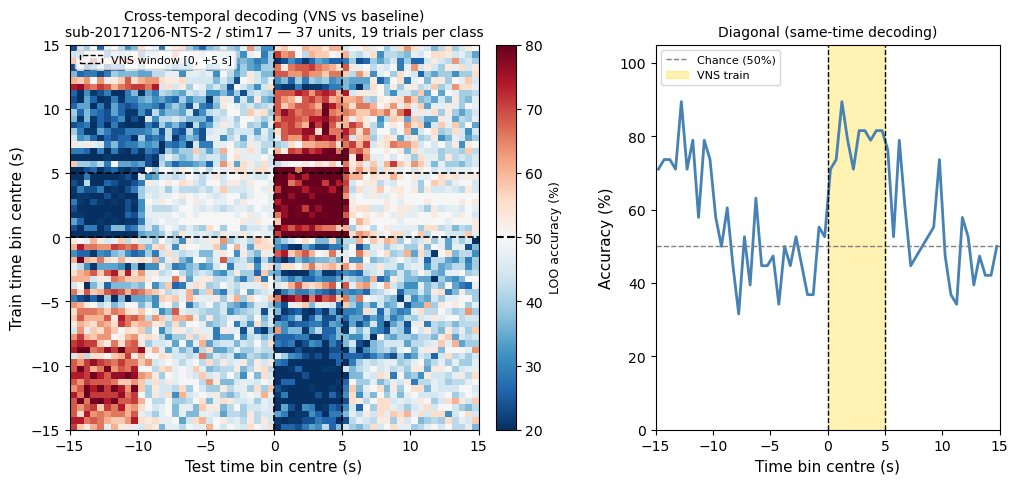

Mean accuracy (pre-VNS  bins): 56.1%
Mean accuracy (VNS      bins): 78.9%
Mean accuracy (post-VNS bins): 52.1%


In [6]:
fig = plt.figure(figsize=(12, 5))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.35)

# ── 2-D matrix ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
im  = ax1.imshow(acc_matrix * 100, origin='lower', aspect='auto',
               extent=[bins_epoch[0], bins_epoch[-1], bins_epoch[0], bins_epoch[-1]],
               cmap='RdBu_r', vmin=20, vmax=80, interpolation='nearest')

# VNS-period lines
for ax_ref in [ax1]:
    ax_ref.axhline(0,       color='k', linewidth=1.2, linestyle='--')
    ax_ref.axhline(WIN_DUR, color='k', linewidth=1.2, linestyle='--')
    ax_ref.axvline(0,       color='k', linewidth=1.2, linestyle='--')
    ax_ref.axvline(WIN_DUR, color='k', linewidth=1.2, linestyle='--')

ax1.set_xlabel('Test time bin centre (s)', fontsize=11)
ax1.set_ylabel('Train time bin centre (s)', fontsize=11)
ax1.set_title(f'Cross-temporal decoding (VNS vs baseline)\n{SUBJECT} / {STIM} — {len(good_ids)} units, {n_trials} trials per class', fontsize=10)
cb = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cb.set_label('LOO accuracy (%)', fontsize=9)
cb.ax.axhline(50, color='k', linewidth=1.5, linestyle='--')

# VNS window patch legend
vns_patch = mpatches.Patch(facecolor='none', edgecolor='black', linestyle='--', label=f'VNS window [0, +{WIN_DUR:.0f} s]')
ax1.legend(handles=[vns_patch], loc='upper left', fontsize=8)

# ── diagonal (time-resolved accuracy) ───────────────────────────────────
ax2 = fig.add_subplot(gs[1])
diag = np.diag(acc_matrix) * 100
ax2.plot(bin_centres, diag, color='steelblue', linewidth=2)
ax2.axhline(50, color='gray', linewidth=1, linestyle='--', label='Chance (50%)')
ax2.axvspan(0, WIN_DUR, color='gold', alpha=0.3, label='VNS train')
ax2.axvline(0,       color='k', linewidth=1, linestyle='--')
ax2.axvline(WIN_DUR, color='k', linewidth=1, linestyle='--')
ax2.set_xlabel('Time bin centre (s)', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_ylim(0, 105)
ax2.set_xlim(bins_epoch[0], bins_epoch[-1])
ax2.set_title('Diagonal (same-time decoding)', fontsize=10)
ax2.legend(fontsize=8)

plt.savefig('vns_cross_temporal_decoding.png', dpi=150, bbox_inches='tight')
plt.show()

# print diagonal summary
vns_mask  = (bin_centres >= 0) & (bin_centres < WIN_DUR)
pre_mask  = bin_centres < 0
post_mask = bin_centres >= WIN_DUR
print(f'Mean accuracy (pre-VNS  bins): {diag[pre_mask].mean():.1f}%')
print(f'Mean accuracy (VNS      bins): {diag[vns_mask].mean():.1f}%')
print(f'Mean accuracy (post-VNS bins): {diag[post_mask].mean():.1f}%')